In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.feature_extraction.text import CountVectorizer

# Define path
file_path = os.path.join('..', 'data', 'raw_analyst_ratings.csv')

# Load data
df = pd.read_csv(file_path)

# Data Cleaning: Convert date and drop invalid entries
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date', 'headline'])

print(f"Dataset loaded with {df.shape[0]} valid rows.")
df.head()

ModuleNotFoundError: No module named 'sklearn'

In [2]:
# Convert date to datetime objects and handle errors
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Check for rows that didn't convert correctly
print(f"Missing or invalid dates: {df['date'].isna().sum()}")

Missing or invalid dates: 1351341


In [3]:
# 1. Get basic stats for the text
df['headline_len'] = df['headline'].apply(len)
print(df['headline_len'].describe())

# 2. Count how many articles each publisher has
print("\nTop 5 Publishers:")
print(df['publisher'].value_counts().head(5))

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64

Top 5 Publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Name: count, dtype: int64


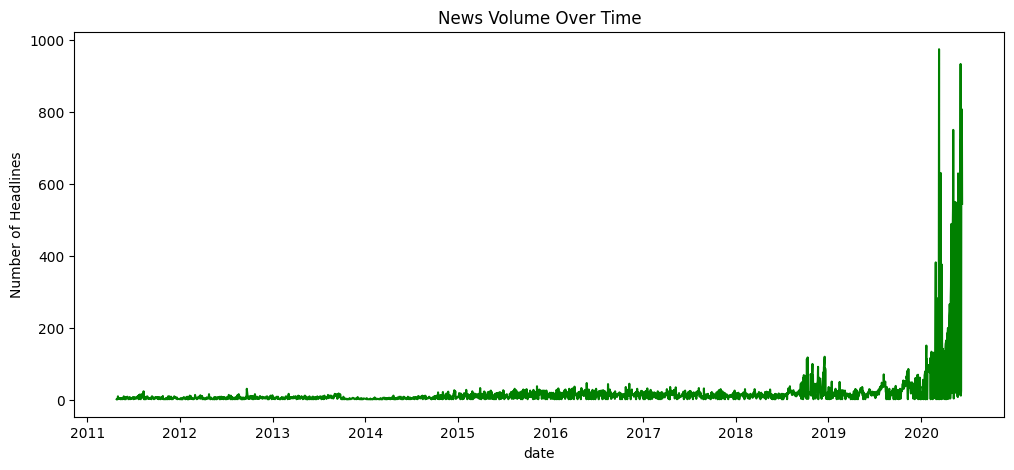

In [4]:
import matplotlib.pyplot as plt

# Ensure date is in the right format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Plot news volume by day
df['date'].dt.date.value_counts().sort_index().plot(figsize=(12, 5), color='green')
plt.title('News Volume Over Time')
plt.ylabel('Number of Headlines')
plt.show()

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

# Look for common "Bigrams" (two-word phrases like "earnings report")
cv = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=10)
bigrams = cv.fit_transform(df['headline'])
counts = pd.DataFrame(bigrams.toarray(), columns=cv.get_feature_names_out()).sum()

print("\nMost Common Phrases:")
print(counts.sort_values(ascending=False))

ModuleNotFoundError: No module named 'sklearn'